In [19]:
import numpy as np

class MarketSimulator:
    def __init__(self, beta_matrix, competitor_designs, market_size):
       
        self.betas = beta_matrix
        self.comp_designs = competitor_designs
        self.market_size = market_size
        
        # Pre-calculate competitor utilities since they remain constant
        # Resulting matrix: (num_respondents, num_competitors)
        self.comp_utilities = np.dot(self.betas, self.comp_designs.T)

    def evaluate_product(self, our_design, our_price, our_cost, price_betas): #Setup main function with inputs expected 
        """
        Evaluates a new product configuration generated by NSGA-II.
        
        our_design: A 2D array of shape (1, num_attribute_levels)
        our_price: Float representing the product price
        our_cost: Float representing the product cost
        """
        # Calculate utility for our new product
        # Resulting matrix: (num_respondents, 1)
        feature_utility = np.dot(self.betas, our_design.T)

        #Adding Price negativity
        #price_betas shape: (num_respondents, 1)
        price_utilities = price_betas * our_price
        our_utility = feature_utility + price_utilities
        
        # Combine all utilities into a single matrix
        # Resulting matrix: (num_respondents, num_competitors + 1)
        all_utilities = np.hstack((self.comp_utilities, our_utility))
        
        # Apply Multinomial Logit (MNL) rule
        exp_utilities = np.exp(all_utilities)
        probabilities = exp_utilities / np.sum(exp_utilities, axis=1, keepdims=True)
        
        # Extract the probability column for our product (the last column)
        our_probabilities = probabilities[:, -1]
        
        # Calculate final objectives
        market_share = np.mean(our_probabilities)
        unit_sales = market_share * self.market_size
        profit = unit_sales * (our_price - our_cost)
        
        return market_share, profit

In [20]:
import numpy as np
# --- Define product attributes here (edit this to change the product structure) ---
# Format: ("Attribute Name", number_of_levels)
attributes = [
    ("Wire Diameter", 3),   # Add attributes here for reference > 1.25mm, 2.00mm, 2.50mm
    ("Amperage",      2),   # Add attributes here for reference > 3A, 5A
    ("Cycles",        2),   # Add attributes here for reference > 50 cycles, 100 cycles
]

# --- Define your competitors ---
# "levels" is a list of which level each attribute is set to (0-indexed)
# Must have one entry per attribute, in the same order
competitors = [
    {"name": "Competitor A", "price": 2.00, "levels": [0, 0, 0]},  # 1.25mm, 3A, 50 cycles
    {"name": "Competitor B", "price": 3.50, "levels": [2, 1, 1]},  # 2.50mm, 5A, 100 cycles
    {"name": "Competitor C", "price": 5.00, "levels": [2, 1, 0]}
]

# Automatically derive everything else — DO NOT TOUCH !!!
num_levels     = [a[1] for a in attributes]
total_levels   = sum(num_levels)
start_indices  = [sum(num_levels[:i]) for i in range(len(num_levels))]

# Build the competitor matrix from the levels defined above
competitor_matrix = np.zeros((len(competitors), total_levels), dtype=int)
for row, comp in enumerate(competitors):
    for attr_i, level_choice in enumerate(comp["levels"]):
        competitor_matrix[row, start_indices[attr_i] + level_choice] = 1

comp_prices = np.array([[c["price"]] for c in competitors])

print(f"Competitor matrix:\n{competitor_matrix}")
print(f"Competitor prices: {comp_prices.flatten()}")

# Dummy survey
np.random.seed(42) 
num_respondents = 100
dummy_betas = np.random.normal(loc=0.0, scale=1.5, size=(num_respondents, total_levels))

market_size = int(input("Enter the total market size (e.g., 50000): "))
our_price = float(input("Enter our product price in dollars (e.g., 2.50): "))
our_cost = float(input("Enter our product unit cost in dollars (e.g., 0.85): "))
price_min, price_max = map(float, input("Enter the price search range (e.g., 1.00-5.00): ").split("-"))
if price_min <= our_cost:
    price_min = our_cost
    print(f"Warning: Minimum Price was set below cost. Adjusted to ${price_min: .2f}")

# Generate negative price sensitivities for 100 respondents
# Average sensitivity is -0.8 utility points per dollar
price_betas = np.random.normal(loc=-0.8, scale=0.2, size=(num_respondents, 1))

# Initialize the Simulator
simulator = MarketSimulator(dummy_betas, competitor_matrix, market_size)
# Update the competitor utility calculation to include their prices
# (num_respondents, num_competitors) + (num_respondents, 1) * (1, num_competitors)
simulator.comp_utilities += np.dot(price_betas, comp_prices.T)

# --- Evaluate a single product ---
# Our product: 2.00mm, 5A, 50 cycles -> levels [1, 1, 0]
our_new_design = np.zeros((1, total_levels), dtype=int)
our_levels = [1, 1, 0]
for attr_i, level_choice in enumerate(our_levels):
    our_new_design[0, start_indices[attr_i] + level_choice] = 1

market_share, profit = simulator.evaluate_product(our_new_design, our_price, our_cost, price_betas)

print(f"\nProduct Design String: {our_new_design[0]}")
print(f"Price: ${our_price:.2f} | Cost: ${our_cost:.2f}")
print(f"Calculated Market Share: {market_share * 100:.2f}%")
print(f"Projected Profit: ${profit:,.2f}")

Competitor matrix:
[[1 0 0 1 0 1 0]
 [0 0 1 0 1 0 1]
 [0 0 1 0 1 1 0]]
Competitor prices: [2.  3.5 5. ]


Enter the total market size (e.g., 50000):  100000
Enter our product price in dollars (e.g., 2.50):  2
Enter our product unit cost in dollars (e.g., 0.85):  0.6
Enter the price search range (e.g., 1.00-5.00):  0.4-5.0



Product Design String: [0 1 0 0 1 1 0]
Price: $2.00 | Cost: $0.60
Calculated Market Share: 37.32%
Projected Profit: $52,252.11


In [21]:
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
import numpy as np

class Optimizer(ElementwiseProblem):
    def __init__(self, sim, price_betas, attributes, our_cost, price_min, price_max):
        
        # Derive structure from attributes
        self.num_levels    = [a[1] for a in attributes]
        self.total_levels  = sum(self.num_levels)
        self.start_indices = [sum(self.num_levels[:i]) for i in range(len(self.num_levels))]
        self.sim           = sim
        self.price_betas   = price_betas
        self.our_cost      = our_cost

        # Build bounds dynamically
        # Each attribute variable ranges from 0 to (num_levels - 1)
        # Price is always the last variable, ranging from $1.00 to $5.00
        lower = np.array([0          for n in self.num_levels] + [price_min])
        upper = np.array([n - 1      for n in self.num_levels] + [price_max])

        super().__init__(n_var=len(attributes) + 1, n_obj=2, xl=lower, xu=upper)

    def _evaluate(self, x, out, *args, **kwargs):
        
        # Build the one-hot design vector dynamically
        design = np.zeros((1, self.total_levels))
        
        for i, start in enumerate(self.start_indices):
            chosen_level = int(round(x[i]))
            design[0, start + chosen_level] = 1

        price = x[-1]  # price is always the last variable

        share, profit = self.sim.evaluate_product(design, price, self.our_cost, self.price_betas)
        out["F"] = [-share, -profit]

# --- Execute and Print ---
res = minimize(Optimizer(simulator, price_betas, attributes, our_cost, price_min, price_max), NSGA2(pop_size=100), ('n_gen', 100))

print(f"Found {len(res.F)} optimal solutions:\n" + "-"*45)

for share, profit, price in zip(-res.F[:, 0], -res.F[:, 1], res.X[:, len(attributes)]):
    print(f"Share: {share*100:5.2f}% | Profit: ${profit:8.2f} | Price: ${price:5.2f}")

Found 100 optimal solutions:
---------------------------------------------
Share: 23.94% | Profit: $70720.45 | Price: $ 3.55
Share: 58.26% | Profit: $    0.00 | Price: $ 0.60
Share: 23.94% | Profit: $70720.45 | Price: $ 3.55
Share: 51.86% | Profit: $24934.86 | Price: $ 1.08
Share: 43.35% | Profit: $48569.94 | Price: $ 1.72
Share: 45.18% | Profit: $44501.83 | Price: $ 1.59
Share: 56.56% | Profit: $ 6163.60 | Price: $ 0.71
Share: 56.97% | Profit: $ 4708.71 | Price: $ 0.68
Share: 42.17% | Profit: $50932.85 | Price: $ 1.81
Share: 32.23% | Profit: $64391.68 | Price: $ 2.60
Share: 46.12% | Profit: $42201.75 | Price: $ 1.52
Share: 35.01% | Profit: $61074.36 | Price: $ 2.34
Share: 55.03% | Profit: $12772.40 | Price: $ 0.83
Share: 35.91% | Profit: $60175.18 | Price: $ 2.28
Share: 42.84% | Profit: $49602.18 | Price: $ 1.76
Share: 51.04% | Profit: $27774.66 | Price: $ 1.14
Share: 33.52% | Profit: $62560.28 | Price: $ 2.47
Share: 48.41% | Profit: $35984.39 | Price: $ 1.34
Share: 55.40% | Profit: $

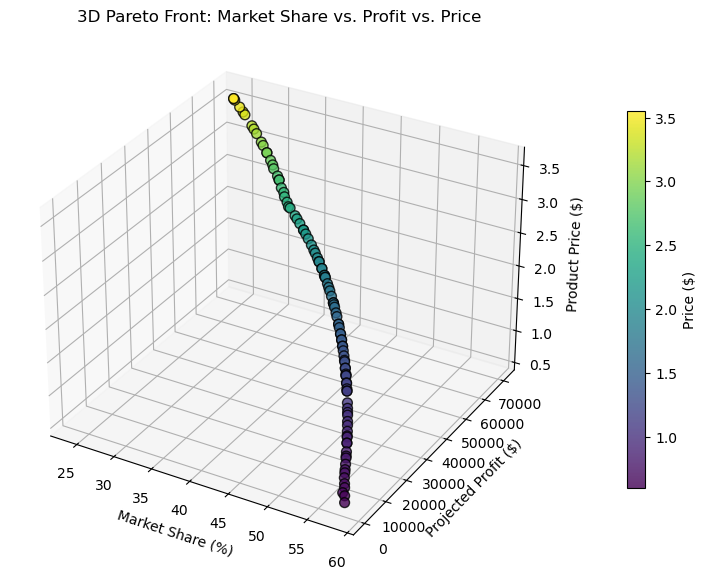

In [22]:
import matplotlib.pyplot as plt

# Extract the final values from your Pymoo results
market_share = -res.F[:, 0] * 100
profit = -res.F[:, 1]
prices = res.X[:, len(attributes)]

# Set up the 3D figure
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Create the 3D scatter plot
# Using a subtle color gradient along the Z-axis (price) for extra clarity
scatter = ax.scatter(market_share, profit, prices, c=prices, cmap='viridis', s=50, alpha=0.8, edgecolors='black')

# Add professional labels and formatting
ax.set_title("3D Pareto Front: Market Share vs. Profit vs. Price")
ax.set_xlabel("Market Share (%)")
ax.set_ylabel("Projected Profit ($)")
ax.set_zlabel("Product Price ($)")

# Add a color bar legend for the exact price values
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("Price ($)")

# Display the interactive 3D graph
plt.show()